In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import pandas as pd
from IPython.display import HTML
import time

from numcosmo_py import Nc, Ncm, sky_match
from numcosmo_py.sky_match import (
    BestCandidates,
    Coordinates,
    DistanceMethod,
    SelectionCriteria,
    SkyMatch,
    SkyMatchResult,
)
import sys
from astropy import units as u
from numcosmo_py.plotting.tools import set_rc_params_article, confidence_ellipse
from astropy.coordinates import SkyCoord, Angle
from scipy.special import erf
set_rc_params_article(ncol=1)
Ncm.cfg_init()
sys.path.insert(0, "../")
from generate_mock import generate_halo_cluster, HOD_model, generate_halo_galaxies, generate_cluster_galaxies, sharing_galaxies
import pandas as pd
Omega_b = 0.0486
Omega_c = 0.2614
Omega_k = 0.0
H0 = 67.7

#Omega_b = 0.05
#Omega_c = 0.25
#Omega_k = 0.0
#H0 = 70.0

# Create a cosmology object
cosmo = Nc.HICosmoDEXcdm.new()
cosmo.omega_x2omega_k()
cosmo["Omegab"] = Omega_b
cosmo["Omegac"] = Omega_c
cosmo["Omegak"] = Omega_k
cosmo["H0"] = H0
cosmo["w"] = -1.0

dist = Nc.Distance.new(100.0)
dist.compute_inv_comoving(True)
dist.prepare(cosmo)

In [2]:
# Lets fix the numpy seed to get reproducible results
np.random.seed(74682)
halo_properties  = {"Mass":"halo_mass","halo_id":"halo_id", "R200":"R200"}
halo_member_properties  = {"halo_mass":"halo_mass","halo_id":"halo_id", "galaxy_id":"galaxy_id"}
cluster_properties  = {"Mass":"cluster_mass","cluster_id":"cluster_id", "R200":"R200"}
cluster_member_properties  = {"cluster_mass":"cluster_mass","cluster_id":"cluster_id", "galaxy_id":"galaxy_id"}


%time halos, clusters = generate_halo_cluster(cosmo,dist,200,100)
%time halo_galaxies = generate_halo_galaxies(halos, cosmo,dist)
%time cluster_galaxies = generate_cluster_galaxies(clusters, cosmo,dist)
%time halo_galaxies_shared = sharing_galaxies(halos,halo_galaxies,cluster_galaxies, cosmo, halo_properties, cluster_member_properties, "halo")
%time cluster_galaxies_shared = sharing_galaxies(clusters,cluster_galaxies,halo_galaxies, cosmo, cluster_properties, halo_member_properties, "cluster")

CPU times: user 2.86 ms, sys: 0 ns, total: 2.86 ms
Wall time: 2.66 ms
Generated 566 galaxies from 200 halos.
CPU times: user 166 ms, sys: 6.5 ms, total: 173 ms
Wall time: 177 ms
Generated 464 galaxies from 100 clusters.
CPU times: user 74.5 ms, sys: 1.48 ms, total: 76 ms
Wall time: 77.6 ms
CPU times: user 203 ms, sys: 5.65 ms, total: 209 ms
Wall time: 243 ms
CPU times: user 185 ms, sys: 6.95 ms, total: 192 ms
Wall time: 194 ms


# Scale marker sizes with log mass
def scale_marker_size(log_mass, base_size=20, scale_factor=30):
    arr = scale_factor * (log_mass - LOGM_MIN)
    return base_size + np.where(arr < 0, 0, arr)


cluster_sizes = scale_marker_size(cluster_logm)
halo_sizes = scale_marker_size(halo_logm)

fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot for clusters (fixed red color)
ax.scatter(
    cluster_ra,
    cluster_dec,
    c=cluster_z,
    cmap="Reds",
    s=cluster_sizes,
    label="Clusters",
    alpha=0.7,
    vmin=0.0,
)

# Scatter plot for halos (color varies with z, from light to dark blue)
halo_scatter = ax.scatter(
    halo_ra,
    halo_dec,
    c=halo_z,
    cmap="Blues",
    s=halo_sizes,
    label="Halos",
    alpha=0.7,
    vmin=0.0,
)

# Colorbar to indicate redshift values
color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_xlim(RA_MIN, RA_MAX)
ax.set_ylim(DEC_MIN, DEC_MAX)
ax.legend()
plt.tight_layout()
plt.savefig("halos_clusters.pdf")
plt.show()

# Matching by ID

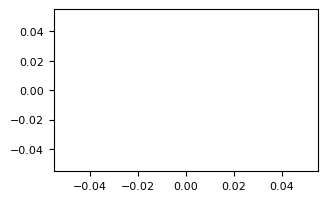

In [3]:
halo_test = halo_galaxies_shared[halo_galaxies_shared['halo_id'] == 209968]
cluster_test = cluster_galaxies[cluster_galaxies['cluster_id'] == 109968]

plt.scatter(cluster_test['RA'], cluster_test['DEC'])
plt.scatter(halo_test['RA'],halo_test['DEC'],alpha=0.4)

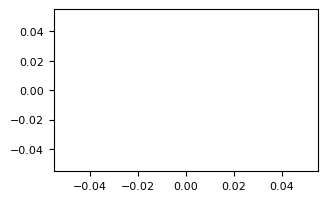

In [4]:
halo_test = halo_galaxies_shared[halo_galaxies_shared['halo_id'] == 209998]
cluster_test = cluster_galaxies[cluster_galaxies['cluster_id'] == 109998]

plt.scatter(cluster_test['RA'], cluster_test['DEC'])
plt.scatter(halo_test['RA'],halo_test['DEC'],alpha=0.4)

In [5]:
halo_coordinates = {"RA":"RA" , "DEC":"DEC" , "z":"z"}
halo_ids  = {"ID": "halo_id", "MemberID": "galaxy_id"}

detections_coordinates =  {"RA":"RA" , "DEC":"DEC" , "z":"z"}
detections_ids  = {"ID": "cluster_id", "MemberID": "galaxy_id"}


halos_m = sky_match.SkyMatch(
    query_data= halos,
    query_coordinates=halo_coordinates,
    query_member_data=halo_galaxies_shared,
    query_ids = halo_ids, 
    match_data=clusters,
    match_coordinates=detections_coordinates,
    match_member_data=cluster_galaxies,
    match_ids = detections_ids
)

detections_m = halos_m.invert_query_match()

In [6]:
%time halos_matched = halos_m.match_ID()
%time best_halos = halos_matched.select_best()
%time best_halos_table = halos_matched.to_table_best(best_halos)

CPU times: user 12.1 ms, sys: 69 μs, total: 12.2 ms
Wall time: 12 ms
CPU times: user 8.16 ms, sys: 114 μs, total: 8.28 ms
Wall time: 8.28 ms
CPU times: user 267 μs, sys: 179 μs, total: 446 μs
Wall time: 450 μs


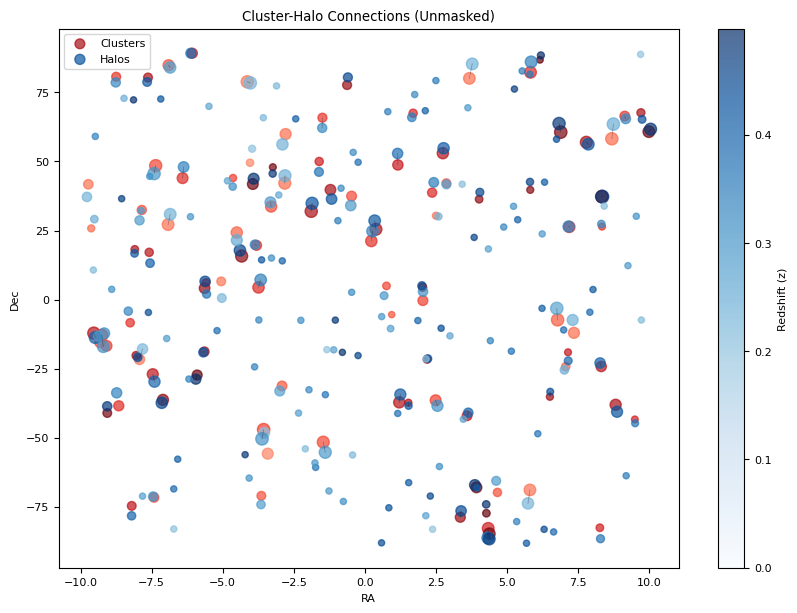

In [7]:
cluster_ra = clusters['RA']
cluster_sin_dec = np.sin(clusters['DEC'])
cluster_dec = np.degrees(np.arcsin(cluster_sin_dec))
cluster_z = clusters['z']
cluster_logm = clusters['Mass']

halo_ra = halos['RA']
halo_sin_dec = np.sin(halos['DEC'])
halo_dec = np.degrees(np.arcsin(halo_sin_dec))
halo_z = halos['z']
halo_logm = halos['Mass']

LOGM_MIN, LOGM_MAX = 13.0, 15.0 

def scale_marker_size(log_mass, base_size=20, scale_factor=30):
    arr = scale_factor * (log_mass - LOGM_MIN)
    return base_size + np.where(arr < 0, 0, arr)

cluster_sizes = scale_marker_size(cluster_logm)
halo_sizes = scale_marker_size(halo_logm)

def plot_no_mask():
    fig, ax = plt.subplots(figsize=(10, 7))
    #fig, ax = plt.subplots()

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Plot lines connecting clusters to ALL matched halos (no mask filtering)
    # idx contains the indices of the nearest neighbors for each cluster
    for i, idx in enumerate(halos_matched.nearest_neighbours_indices):

        for halo_i in idx:
            if halo_i is None:
                continue
            halo_pos = halo_i - 100000
            ax.plot(
                [cluster_ra[i], halo_ra[halo_pos]],
                [cluster_dec[i], halo_dec[halo_pos]],
                color="black",
                alpha=0.3, # Lower alpha helps if lines are very dense
                linewidth=0.5
            )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    ax.set_title("Cluster-Halo Connections (Unmasked)")

    return fig

# Execute the plot
plot_no_mask()
plt.savefig("multipe_match_id.pdf")
plt.show()

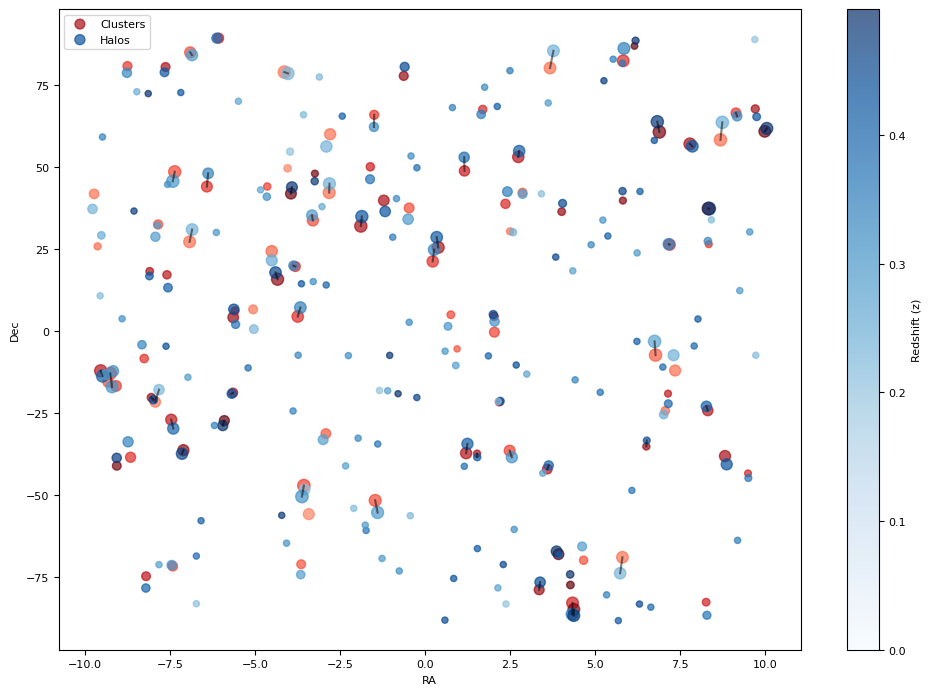

In [8]:
cluster_ra = clusters['RA']
cluster_sin_dec = np.sin(clusters['DEC'])
cluster_dec = np.degrees(np.arcsin(cluster_sin_dec))
cluster_z = clusters['z']
cluster_logm = clusters['Mass']

halo_ra = halos['RA']
halo_sin_dec = np.sin(halos['DEC'])
halo_dec = np.degrees(np.arcsin(halo_sin_dec))
halo_z = halos['z']
halo_logm = halos['Mass']

LOGM_MIN, LOGM_MAX = 13.0, 15.0 

def scale_marker_size(log_mass, base_size=20, scale_factor=30):
    arr = scale_factor * (log_mass - LOGM_MIN)
    return base_size + np.where(arr < 0, 0, arr)

cluster_sizes = scale_marker_size(cluster_logm)
halo_sizes = scale_marker_size(halo_logm)


def plot_best():
    fig, ax = plt.subplots(figsize=(10, 7))
    #fig, ax = plt.subplots()

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Plot lines connecting clusters to ALL matched halos (no mask filtering)
    # idx contains the indices of the nearest neighbors for each cluster
    for cluster_i, halo_i in zip(best_halos.query_indices, best_halos.indices):
        ax.plot(
            [cluster_ra[cluster_i], halo_ra[halo_i]],
            [cluster_dec[cluster_i], halo_dec[halo_i]],
            color="black",
            alpha=0.5,
        )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    plt.tight_layout()
    return fig

    return fig

# Execute the plot
plot_best()
plt.savefig("cross_match_id.pdf")
plt.show()

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Aggregate data from the halo catalog
# Find unique halos and their total galaxy counts
unique_h_ids, h_counts = np.unique(galaxy_halo_catalog['halo_id'], return_counts=True)

h_masses = []
h_n_centrals = []

for hid in unique_h_ids:
    # Filter rows belonging to this specific halo
    halo_rows = galaxy_halo_catalog[galaxy_halo_catalog['halo_id'] == hid]
    
    # Grab the mass (using the column name from your halo catalog)
    h_masses.append(halo_rows['halo_mass'][0])
    
    # Count how many are centrals
    h_n_centrals.append(np.sum(halo_rows['is_central']))

# Convert to arrays for calculation
h_masses = np.array(h_masses)
h_total_gals = np.array(h_counts)
h_n_centrals = np.array(h_n_centrals)
h_n_satellites = h_total_gals - h_n_centrals

# 2. Plotting
plt.figure(figsize=(10, 6))

# Plot Total count (Halos)
plt.scatter(h_masses, h_total_gals, color='black', alpha=0.6, label='Total Galaxies ($N_{tot}$)', s=30)

# Plot Centrals (Halos)
plt.scatter(h_masses, h_n_centrals, color='red', marker='x', label='Centrals ($N_{cen}$)', s=50)

# Plot Satellites (Halos)
plt.scatter(h_masses, h_n_satellites, color='blue', marker='.', label='Satellites ($N_{sat}$)', s=20)

# Standard HOD plots usually use log scale for Y, 
# but I've left it commented out per your previous code style.
# plt.yscale('log')

plt.xlabel(r'$\log_{10}(M_{halo} / M_{\odot})$', fontsize=12)
plt.ylabel('Number of Galaxies', fontsize=12)
plt.title('HOD Reconstruction from Halo Catalog')
plt.grid(True, which="both", ls="-", alpha=0.15)
plt.yscale("log")
plt.legend()

plt.show()

NameError: name 'galaxy_halo_catalog' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Aggregate data from the halo catalog
# Find unique halos and their total galaxy counts
unique_h_ids, h_counts = np.unique(galaxy_cluster_catalog['cluster_id'], return_counts=True)

h_masses = []
h_n_centrals = []

for hid in unique_h_ids:
    # Filter rows belonging to this specific halo
    halo_rows = galaxy_cluster_catalog[galaxy_cluster_catalog['cluster_id'] == hid]
    
    # Grab the mass (using the column name from your halo catalog)
    h_masses.append(halo_rows['cluster_mass'][0])
    
    # Count how many are centrals
    h_n_centrals.append(np.sum(halo_rows['is_central']))

# Convert to arrays for calculation
h_masses = np.array(h_masses)
h_total_gals = np.array(h_counts)
h_n_centrals = np.array(h_n_centrals)
h_n_satellites = h_total_gals - h_n_centrals

# 2. Plotting
plt.figure(figsize=(10, 6))

# Plot Total count (Halos)
plt.scatter(h_masses, h_total_gals, color='black', alpha=0.6, label='Total Galaxies ($N_{tot}$)', s=30)

# Plot Centrals (Halos)
plt.scatter(h_masses, h_n_centrals, color='red', marker='x', label='Centrals ($N_{cen}$)', s=50)

# Plot Satellites (Halos)
plt.scatter(h_masses, h_n_satellites, color='blue', marker='.', label='Satellites ($N_{sat}$)', s=20)

# Standard HOD plots usually use log scale for Y, 
# but I've left it commented out per your previous code style.
plt.yscale('log')

plt.xlabel(r'$\log_{10}(M_{cluster} / M_{\odot})$', fontsize=12)
plt.ylabel('Number of Galaxies', fontsize=12)
plt.title('HOD Reconstruction from Halo Catalog')
plt.grid(True, which="both", ls="-", alpha=0.15)
plt.legend()

plt.show()